# Health Insurance Quoting system

## Step 1: Data Generation

In Order to generate synthetic data to build a health insurance quoting system that closely matches real world; I use age limits used by insurance firms (19 to 75); CSO 2024 health data and gov.ie as source of ground truth.

gov.ie:

Weight of the synthetic data is extrapolated from Irish health survey 2024: https://assets.gov.ie/static/documents/3d4f1d01/Healthy_Ireland_Summary_Report_2024_-_Web.pdf

CSO 2024:

Mean Male height: 175.6

Mean Female height: 162.2

Weights are added to increase correlation between height and weight.

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)
N = 2000

gender = np.random.choice(["Male", "Female"], N)

# Using 75 as age limit as it is the standard for first time application
age = np.random.randint(18, 75, N)

# Using CSO 2024 data to get mean height in Ireland across gender
height = np.where(
    gender == "Male",
    np.random.normal(175.6, 7, N),
    np.random.normal(162.2, 6, N)
).round(1)

#Clipping height to stay in range of 140 to 210 cm
height = np.clip(height, 140, 210)

weight = np.where(
    gender == "Male",
    np.random.normal(81, 13, N),
    np.random.normal(66.8, 11, N)
).round(1)

height_effect = (height - height.mean()) * 0.10
weight = weight + height_effect

#Clipping weight to stay in range of 45 to 200 kg
weight = np.clip(weight, 45, 200).round(1)

df = pd.DataFrame({
    "applicationID": range(1, N + 1),
    "gender": gender,
    "age": age,
    "height": height,
    "weight": weight
})

df.to_csv("../data/applicants.csv", index=False)
print(df.shape)
print(df.head())

(2000, 5)
   applicationID  gender  age  height  weight
0              1    Male   64   175.0    45.0
1              2  Female   29   162.0    66.2
2              3    Male   33   168.2    90.8
3              4    Male   41   178.6    59.3
4              5    Male   36   174.3    73.7


## Step 2: BMI Calculation

In [3]:
def calculate_bmi(weight, height):
    #Calculate BMI given weight in kg and height in cm.
    bmi = round(weight / (height / 100) ** 2, 2)
    return bmi

df["bmi"] = calculate_bmi(df["weight"], df["height"])

print(df.head())

   applicationID  gender  age  height  weight    bmi
0              1    Male   64   175.0    45.0  14.69
1              2  Female   29   162.0    66.2  25.22
2              3    Male   33   168.2    90.8  32.09
3              4    Male   41   178.6    59.3  18.59
4              5    Male   36   174.3    73.7  24.26


In [4]:
# Performing descriptive statistics
print(df.describe())

       applicationID          age       height       weight          bmi
count    2000.000000  2000.000000  2000.000000  2000.000000  2000.000000
mean     1000.500000    45.667500   168.750950    73.700850    25.904635
std       577.494589    16.275146     9.487776    14.330837     4.718388
min         1.000000    18.000000   143.100000    45.000000    13.080000
25%       500.750000    32.000000   161.800000    63.000000    22.717500
50%      1000.500000    46.000000   168.300000    73.100000    25.705000
75%      1500.250000    60.000000   175.725000    82.800000    29.082500
max      2000.000000    74.000000   196.500000   121.800000    42.610000


Mean BMI closely matches with Irish health data of 25.9.

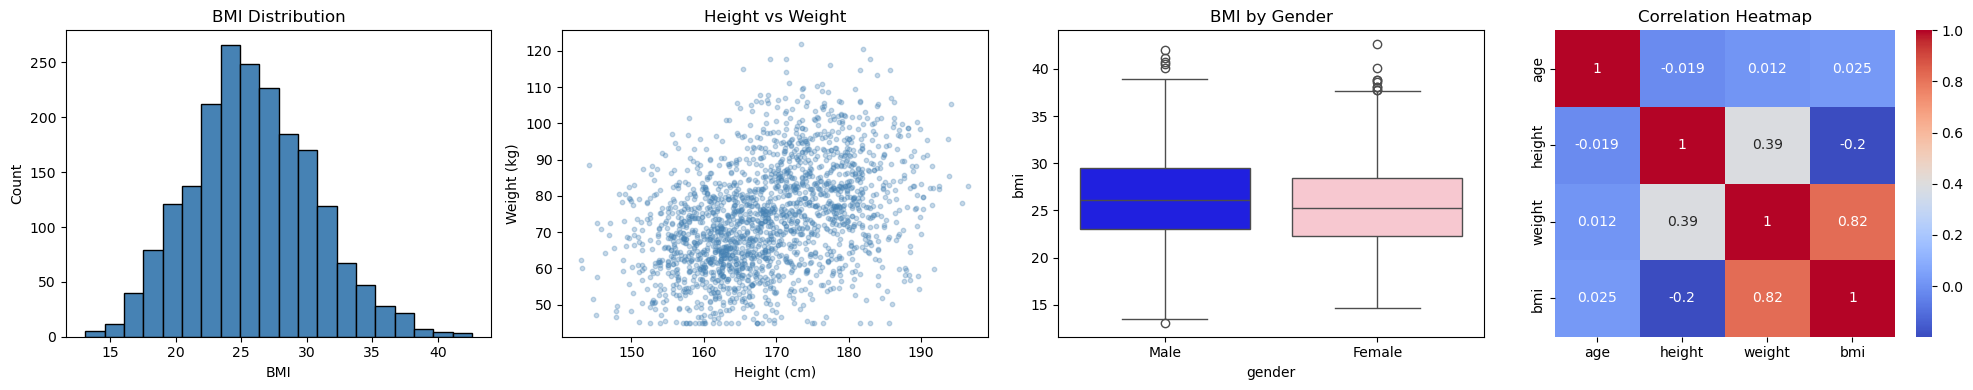

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# BMI distribution
axes[0].hist(df["bmi"], bins=20, edgecolor="black", color="steelblue")
axes[0].set_title("BMI Distribution")
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Count")

# Height vs Weight scatter
axes[1].scatter(df["height"], df["weight"], alpha=0.3, color="steelblue", s=10)
axes[1].set_title("Height vs Weight")
axes[1].set_xlabel("Height (cm)")
axes[1].set_ylabel("Weight (kg)")

# BMI by gender boxplot
sns.boxplot(x="gender", y="bmi", data=df, hue="gender", 
            palette={"Male": "blue", "Female": "pink"}, 
            legend=False, ax=axes[2])
axes[2].set_title("BMI by Gender")

# Correlation heatmap
sns.heatmap(df[["age", "height", "weight", "bmi"]].corr(), 
            annot=True, cmap="coolwarm", ax=axes[3])
axes[3].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

Height x Weight Correlation: 0.39, Weight x BMI Correlation: 0.82 and Height x BMI correlation of -0.2 roughly matches real world data.

## Step 3: Machine Learning Model Development

In [6]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.preprocessing import OneHotEncoder

# One-hot encoding gender to avoid implying ordinal relationship between categories
ohe = OneHotEncoder(drop="first", sparse_output=False)
gender_encoded = ohe.fit_transform(df[["gender"]])
df["gender_encoded"] = gender_encoded.astype(int)
df.head()

,applicationID,gender,age,height,weight,bmi,gender_encoded
0,1,Male,64,175.0,45.0,14.69,1
1,2,Female,29,162.0,66.2,25.22,0
2,3,Male,33,168.2,90.8,32.09,1
3,4,Male,41,178.6,59.3,18.59,1
4,5,Male,36,174.3,73.7,24.26,1


In [9]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df[["age", "height", "weight", "gender_encoded"]]
y = df["bmi"]

# Holding out 20% test data set for model evaluation
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

candidates = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Polynomial Regression": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Performing cross validation on training dataset
print("MODEL COMPARISON —> 5-Fold Cross Validation")

results = []
trained_models = {}

for name, model in candidates.items():
    cv_results = cross_validate(
        model, X_train_val, y_train_val, cv=5,
        scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"],
        return_train_score=False
    )
    results.append({
        "Model":     name,
        "R2 Mean":   cv_results["test_r2"].mean().round(4),
        "R2 Std":    cv_results["test_r2"].std().round(4),
        "MAE Mean":  (-cv_results["test_neg_mean_absolute_error"]).mean().round(4),
        "RMSE Mean": (-cv_results["test_neg_root_mean_squared_error"]).mean().round(4),
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values("R2 Mean", ascending=False)
print(results_df.to_string(index=False))

MODEL COMPARISON —> 5-Fold Cross Validation
                Model  R2 Mean  R2 Std  MAE Mean  RMSE Mean
Polynomial Regression   0.9999  0.0000    0.0321     0.0528
    Gradient Boosting   0.9943  0.0008    0.2481     0.3508
        Random Forest   0.9933  0.0012    0.1876     0.3801
    Linear Regression   0.9877  0.0005    0.3441     0.5181


The results shows that Polynomial Regression has provided the best R2 value with lowest MAE and RMSE. The standard deviation value of R2 is very low suggesting the model has memorized the equation. There is no need of consideration about bias variance tradeoff since BMI is a near deterministic function of height and weight and polynomial regression is able to accurately understand the mathematical structure. Polynomial Regression, being the most explainable and auditable; will be chosen as the champion model to implement in prod.

## Step 4: Model evaluation Metrics

In [10]:
# Fit champion on full training data
chosen_model = "Polynomial Regression"
champion = candidates[chosen_model]
champion.fit(X_train_val, y_train_val)

# Final evaluation on held-out test set
y_pred = champion.predict(X_test)

print("=" * 70)
print("FINAL EVALUATION — Held-Out Test Set (20%)")
print("=" * 70)
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R2:   {r2_score(y_test, y_pred):.4f}")

FINAL EVALUATION — Held-Out Test Set (20%)
MAE:  0.0333
RMSE: 0.0481
R2:   0.9999


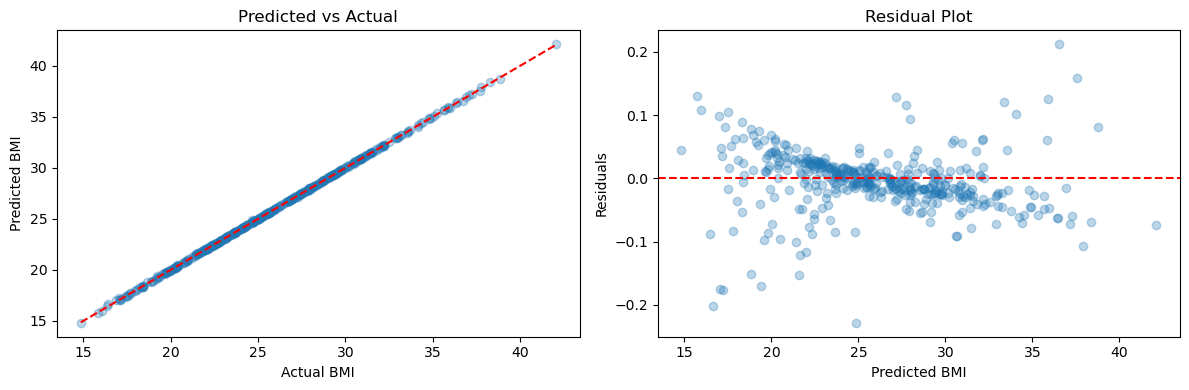

In [11]:
y_pred = champion.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel("Actual BMI")
axes[0].set_ylabel("Predicted BMI")
axes[0].set_title("Predicted vs Actual")

# Plotting residual
axes[1].scatter(y_pred, residuals, alpha=0.3)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel("Predicted BMI")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

## Step 5: Business Rule Engine & Quoting Logic

In [12]:
def rule_engine(age, bmi, gender):
    #return insurance quote based on age, gender and bmi
    if (age >= 18 and age <= 39) and (bmi < 17 or bmi > 37.5):
        base_quote = 800
        reason = "Age is between 18 and 39 and BMI is either less than 17 or greater than 37.5"

    elif (age >= 40 and age <= 59) and (bmi < 18 or bmi > 37.5):
        base_quote = 900
        reason = "Age is between 40 and 59 and BMI is either less than 18 or greater than 37.5"

    elif age >= 60 and (bmi < 18 or bmi > 44.5):
        base_quote = 18000
        reason = "Age is greater than 60 and BMI is either less than 18 or greater than 44.5"

    else:
        base_quote = 600
        reason = "BMI is in the right range"

    # Apply 10% discount for female applicants
    if gender == "Female":
        base_quote = base_quote * 0.90
        reason += " 10% discount added as application gender is female."

    return int(base_quote), reason

# Testing for each case
test_cases = [
    {"age": 25, "bmi": 16, "gender": "Male"},
    {"age": 25, "bmi": 16, "gender": "Female"},
    {"age": 45, "bmi": 20, "gender": "Male"},
    {"age": 45, "bmi": 20, "gender": "Female"},
    {"age": 45, "bmi": 15, "gender": "Male"},
    {"age": 60, "bmi": 45, "gender": "Male"},
    {"age": 60, "bmi": 45, "gender": "Female"},
]

for t in test_cases:
    quote, reason = rule_engine(t["age"], t["bmi"], t["gender"])
    print(quote, reason)

800 Age is between 18 and 39 and BMI is either less than 17 or greater than 37.5
720 Age is between 18 and 39 and BMI is either less than 17 or greater than 37.5 10% discount added as application gender is female.
600 BMI is in the right range
540 BMI is in the right range 10% discount added as application gender is female.
900 Age is between 40 and 59 and BMI is either less than 18 or greater than 37.5
18000 Age is greater than 60 and BMI is either less than 18 or greater than 44.5
16200 Age is greater than 60 and BMI is either less than 18 or greater than 44.5 10% discount added as application gender is female.
